# 08 - Traitement des Données Images

## Section : Gestion des Images

## Objectif
Préparer les images pour la modélisation en :
- Validant et filtrant les images (détection des fichiers corrompus)
- Définissant les paramètres de prétraitement (taille, normalisation)
- Construisant le dataset final image (chemins + labels)
- Sauvegardant les métadonnées pour les notebooks suivants

## Plan
1. Chargement des données (exploration 07)
2. Validation des images (détection des corrompues)
3. Paramètres de prétraitement (224×224, normalisation ImageNet)
4. Construction du dataset final
5. Sauvegarde et statistiques

In [29]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

sys.path.append(str(Path('../').resolve()))

from src.image import load_image_classification_data

ROOT = Path('../').resolve()
DATA_BRUT = ROOT / 'data brut'

IMAGE_DIR_RAW_TRAIN = DATA_BRUT / 'image_train'
IMAGE_DIR_RAW_BRUT = DATA_BRUT / 'image_brut'
IMAGE_DIR_PROCESSED_TRAIN = ROOT / 'data' / 'processed' / 'image_clean'
IMAGE_DIR_PROCESSED_CLEAN = ROOT / 'data' / 'processed' / 'image_clean'

IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def list_image_files(image_dir: Path):
    if not image_dir.exists():
        return []
    return [p for p in image_dir.rglob('*') if p.is_file() and p.suffix.lower() in IMAGE_EXTS]

# Choix du dossier d'images
USE_ONLY_BRUT = True

if USE_ONLY_BRUT:
    IMAGE_DIR = IMAGE_DIR_RAW_BRUT
    IMAGE_SET = 'brut'
else:
    candidates = [
        IMAGE_DIR_RAW_TRAIN,
        IMAGE_DIR_RAW_BRUT,
        IMAGE_DIR_PROCESSED_TRAIN,
        IMAGE_DIR_PROCESSED_CLEAN,
    ]

    print("🔎 Recherche des images...")
    IMAGE_DIR = None
    for candidate in candidates:
        count = len(list_image_files(candidate))
        print(f"   - {candidate} : {count:,} fichiers")
        if count > 0 and IMAGE_DIR is None:
            IMAGE_DIR = candidate

    if IMAGE_DIR is None:
        IMAGE_DIR = IMAGE_DIR_RAW_BRUT

    if IMAGE_DIR in (IMAGE_DIR_RAW_TRAIN, IMAGE_DIR_PROCESSED_TRAIN, IMAGE_DIR_PROCESSED_CLEAN):
        IMAGE_SET = 'train'
    else:
        IMAGE_SET = 'brut'

OUTPUT_DIR = ROOT / 'data' / 'processed'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Configuration chargée")
print(f"📁 Images : {IMAGE_DIR}")
print(f"🧪 Set : {IMAGE_SET}")
if not list_image_files(IMAGE_DIR):
    print("⚠️ Aucun fichier image trouvé (.jpg/.jpeg/.png/.bmp/.webp). Vérifie image_train/image_brut.")

✅ Configuration chargée
📁 Images : C:\Users\pruvost_t\Desktop\Cours\Datascientest_projets\data brut\image_brut
🧪 Set : brut


## 1. Chargement et Construction du Dataset

In [30]:
if IMAGE_SET == 'train':
    print("📥 Chargement dataset train...")
    image_df = load_image_classification_data(DATA_BRUT, IMAGE_DIR, root=ROOT)
    print(f"✅ {len(image_df):,} paires (image, label) chargées")
else:
    print("📥 Chargement dataset brut...")
    image_files = list_image_files(IMAGE_DIR)
    print(f"   - Fichiers images détectés : {len(image_files):,}")
    image_data = []
    for f in image_files:
        try:
            parts = f.stem.split('_')
            if len(parts) >= 4 and parts[0].lower() == 'image' and parts[2].lower() == 'product':
                imageid = int(parts[1])
                productid = int(parts[3])
                try:
                    path_str = str(f.resolve().relative_to(ROOT))
                except ValueError:
                    path_str = str(f.resolve())
                image_data.append({
                    'imageid': imageid,
                    'productid': productid,
                    'image_path': path_str,
                })
        except (ValueError, IndexError):
            pass

    image_df = pd.DataFrame(image_data)
    image_df['prdtypecode'] = np.nan
    print(f"   - Noms d'images parsés : {len(image_df):,}")

    x_test_path = DATA_BRUT / 'X_test_update.csv'
    if x_test_path.exists():
        X_test = pd.read_csv(x_test_path, index_col=0)
        image_df = image_df.merge(X_test, on=['imageid', 'productid'], how='left')
        print(f"✅ {len(image_df):,} images brutes chargées (avec métadonnées si dispo)")
        missing_meta = image_df['designation'].isna().sum() if 'designation' in image_df.columns else 0
        if missing_meta > 0:
            print(f"   ⚠️ {missing_meta:,} images sans métadonnées dans X_test_update.csv")
    else:
        print(f"✅ {len(image_df):,} images brutes chargées (sans métadonnées)")

# Joindre les labels train (Y_train) pour les images d'entrainement
y_train_path = DATA_BRUT / 'Y_train.csv'
x_train_path = DATA_BRUT / 'X_train_update.csv'
if y_train_path.exists() and x_train_path.exists():
    X_tr = pd.read_csv(x_train_path, index_col=0)
    Y_tr = pd.read_csv(y_train_path, index_col=0)
    train_labels = X_tr[['productid', 'imageid']].copy()
    train_labels['prdtypecode'] = Y_tr['prdtypecode'].values
    image_df = image_df.drop(columns=['prdtypecode'], errors='ignore')
    image_df = image_df.merge(
        train_labels[['productid', 'imageid', 'prdtypecode']],
        on=['productid', 'imageid'], how='left'
    )
    n_with_label = image_df['prdtypecode'].notna().sum()
    n_without = image_df['prdtypecode'].isna().sum()
    print(f"   ✅ {n_with_label:,} images train (avec labels)")
    print(f"   📦 {n_without:,} images test (sans labels)")

print(f"   Colonnes : {list(image_df.columns)}")
image_df.head()

📥 Chargement dataset brut...
   - Fichiers images détectés : 46,860
   - Noms d'images parsés : 46,860
✅ 46,860 images brutes chargées (avec métadonnées si dispo)
   ⚠️ 46,860 images sans métadonnées dans X_test_update.csv
   ✅ 46,860 images train (avec labels)
   📦 0 images test (sans labels)
   Colonnes : ['imageid', 'productid', 'image_path', 'designation', 'description', 'prdtypecode']


,imageid,productid,image_path,designation,description,prdtypecode
0,1142089742,884747735,data brut\image_brut\image_1142089742_product_...,NaN,NaN,1320
1,1250268190,3831364140,data brut\image_brut\image_1250268190_product_...,NaN,NaN,2583
2,1250268206,3831364148,data brut\image_brut\image_1250268206_product_...,NaN,NaN,2583
3,1250268214,3831364212,data brut\image_brut\image_1250268214_product_...,NaN,NaN,2583
4,1250268262,3831364233,data brut\image_brut\image_1250268262_product_...,NaN,NaN,2583


## 2. Validation des Images (détection des corrompues)

In [31]:
from PIL import Image

def is_valid_image(path: str, base_dir: Path, min_size: tuple = (10, 10)) -> bool:
    try:
        full_path = base_dir / path if not Path(path).is_absolute() else Path(path)
        with Image.open(full_path) as img:
            img.verify()
        with Image.open(full_path) as img:
            if img.width < min_size[0] or img.height < min_size[1]:
                return False
        return True
    except Exception:
        return False

print("🔄 Validation des images...")
if len(image_df) == 0:
    print("   ⚠️ Aucune image à valider (dataset vide)")
else:
    print(f"   - À valider : {len(image_df):,}")
    valid_mask = [is_valid_image(p, ROOT) for p in image_df['image_path']]
    n_valid = sum(valid_mask)
    n_removed = len(image_df) - n_valid
    if n_removed > 0:
        image_df = image_df[valid_mask].copy()
        print(f"   ⚠️ {n_removed} images corrompues exclues")
    print(f"   ✅ {len(image_df):,} images valides")

if 'prdtypecode' in image_df.columns and image_df['prdtypecode'].notna().any():
    print(f"   ✅ Classes (27) : {image_df['prdtypecode'].nunique()}")
else:
    print("   ⚠️ Pas de labels disponibles (dataset test)")

🔄 Validation des images...
   - À valider : 46,860
   ✅ 46,860 images valides
   ✅ Classes (27) : 27


## 3. Paramètres de Prétraitement

In [32]:
PREPROCESS_CONFIG = {
    'target_size': (224, 224),
    'normalization': 'imagenet',
    'mean': [0.485, 0.456, 0.406],
    'std': [0.229, 0.224, 0.225],
}
print("📋 Paramètres de prétraitement (ResNet/ImageNet) :")
for k, v in PREPROCESS_CONFIG.items():
    print(f"   {k}: {v}")

📋 Paramètres de prétraitement (ResNet/ImageNet) :
   target_size: (224, 224)
   normalization: imagenet
   mean: [0.485, 0.456, 0.406]
   std: [0.229, 0.224, 0.225]


## 4. Sauvegarde du Dataset

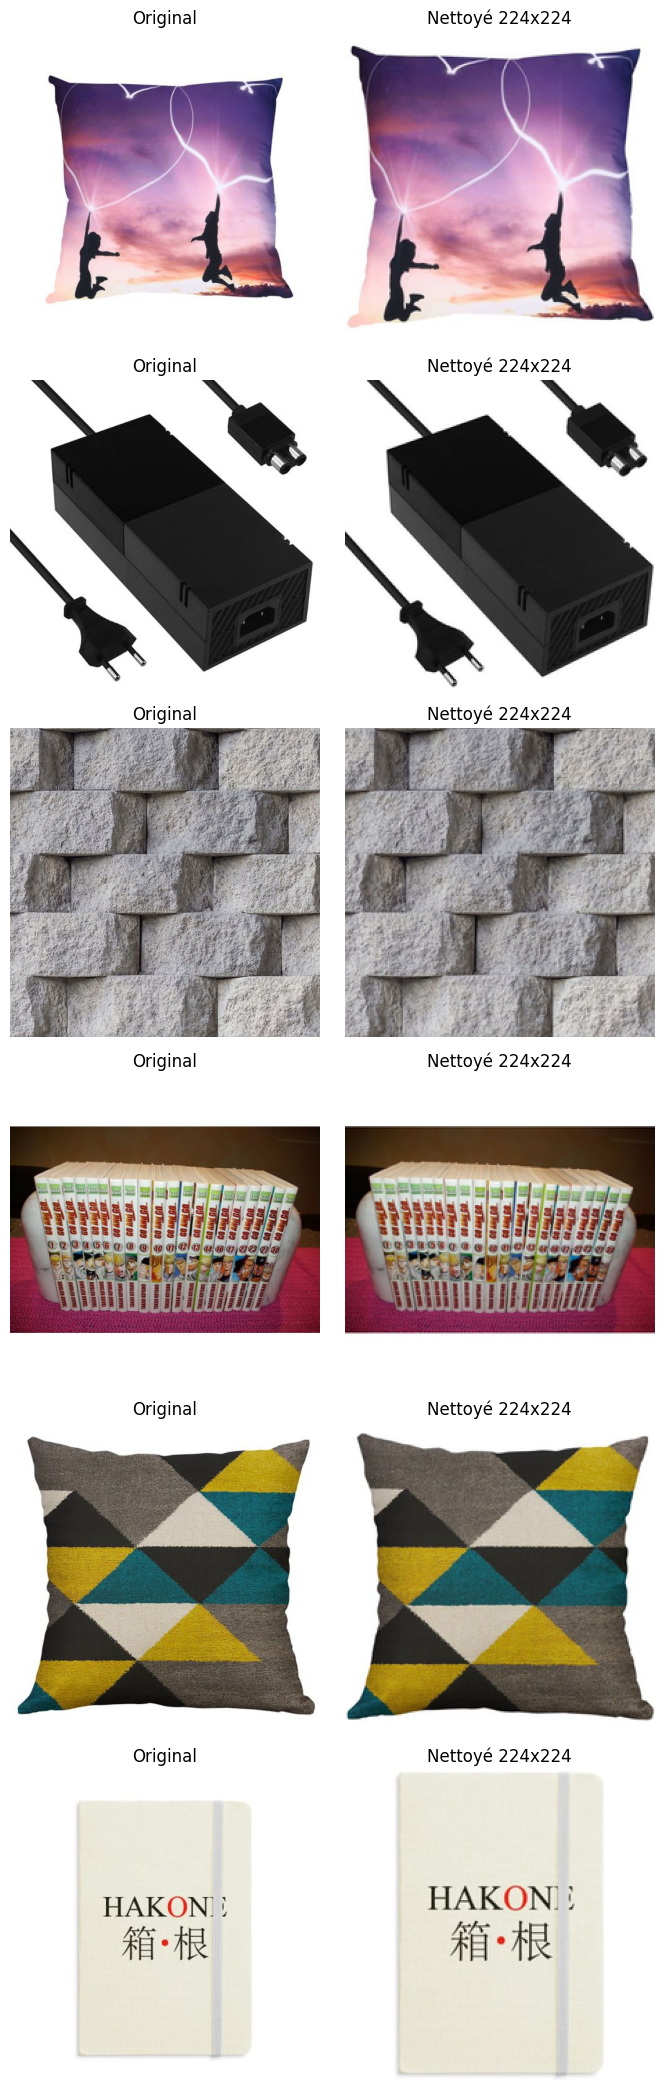

In [33]:
# Nettoyage visuel strict : trim agressif + exclusion quasi-blanches
import matplotlib.pyplot as plt
from PIL import Image

# --- Seuils de nettoyage (plus stricts) ---
WHITE_THRESHOLD = 240          # seuil blanc pour le trim (était 245)
MIN_NONWHITE_PIXELS = 100     # pixels non-blancs min (était 50)
BLANK_MEAN_THRESHOLD = 248     # exclure si luminosité moyenne > 248
MIN_CONTENT_RATIO = 0.02      # exclure si produit < 2% de l'image


def trim_white_borders(img, threshold=WHITE_THRESHOLD, padding=2):
    """Rogne les bandes blanches. Retourne (img_cropée, content_ratio)."""
    arr = np.asarray(img)
    orig_area = arr.shape[0] * arr.shape[1]
    if arr.ndim == 2:
        arr = np.stack([arr] * 3, axis=-1)
    non_white = np.any(arr < threshold, axis=-1)
    if not non_white.any():
        return img, 0.0
    ys, xs = np.where(non_white)
    y0, x0 = ys.min(), xs.min()
    y1, x1 = ys.max() + 1, xs.max() + 1
    y0 = max(0, y0 - padding)
    x0 = max(0, x0 - padding)
    y1 = min(arr.shape[0], y1 + padding)
    x1 = min(arr.shape[1], x1 + padding)
    cropped = img.crop((x0, y0, x1, y1))
    content_ratio = ((x1 - x0) * (y1 - y0)) / orig_area if orig_area > 0 else 0.0
    return cropped, content_ratio


def is_blank(img, threshold=WHITE_THRESHOLD, min_nonwhite=MIN_NONWHITE_PIXELS):
    arr = np.asarray(img)
    if arr.ndim == 2:
        arr = np.stack([arr] * 3, axis=-1)
    non_white = np.any(arr < threshold, axis=-1)
    return int(non_white.sum()) < min_nonwhite


def is_quasi_blank(img, mean_threshold=BLANK_MEAN_THRESHOLD):
    """Exclure les images à luminosité moyenne très élevée."""
    arr = np.asarray(img).astype(np.float32)
    return float(np.mean(arr)) > mean_threshold


def pad_to_square(img, fill=(255, 255, 255)):
    w, h = img.size
    size = max(w, h)
    out = Image.new('RGB', (size, size), fill)
    out.paste(img, ((size - w) // 2, (size - h) // 2))
    return out


def preprocess_image(path, base_dir, target_size=(224, 224)):
    full_path = base_dir / path if not Path(path).is_absolute() else Path(path)
    img = Image.open(full_path).convert('RGB')

    if is_quasi_blank(img):
        return None, {'reason': 'quasi_blank'}

    img, content_ratio = trim_white_borders(img)

    if content_ratio < MIN_CONTENT_RATIO:
        return None, {'reason': 'small_content'}

    if is_blank(img):
        return None, {'reason': 'blank'}

    img = pad_to_square(img)
    img = img.resize(target_size, Image.LANCZOS)
    return img, {'reason': None}


# Aperçu avant/après
sample_paths = []
if len(image_df):
    candidates = image_df['image_path'].dropna().sample(n=min(40, len(image_df)), random_state=42)
    for p in candidates:
        try:
            full_path = ROOT / p if not Path(p).is_absolute() else Path(p)
            img = Image.open(full_path).convert('RGB')
            arr = np.asarray(img)
            if np.mean(arr) < 240:
                sample_paths.append(p)
            if len(sample_paths) >= 6:
                break
        except Exception:
            continue

if sample_paths:
    fig, axes = plt.subplots(len(sample_paths), 2, figsize=(7, 3.5 * len(sample_paths)))
    if len(sample_paths) == 1:
        axes = [axes]
    for i, p in enumerate(sample_paths):
        original = Image.open(ROOT / p if not Path(p).is_absolute() else p).convert('RGB')
        cleaned, flags = preprocess_image(p, ROOT, target_size=PREPROCESS_CONFIG['target_size'])
        axes[i][0].imshow(original)
        axes[i][0].set_title('Original')
        axes[i][0].axis('off')
        if cleaned is None:
            reason_labels = {'quasi_blank': 'quasi-blanche', 'small_content': 'produit < 2%', 'blank': 'blanche'}
            reason = reason_labels.get(flags.get('reason', ''), flags.get('reason', ''))
            axes[i][1].text(0.5, 0.5, f'Exclue\n({reason})', ha='center', va='center')
            axes[i][1].set_title('Exclue')
            axes[i][1].axis('off')
        else:
            axes[i][1].imshow(cleaned)
            axes[i][1].set_title('Nettoyé 224x224')
            axes[i][1].axis('off')
    plt.tight_layout()
else:
    print("⚠️ Aucun sample valable pour l'aperçu")

In [34]:
# Application du nettoyage strict (sans augmentation - le déséquilibre est géré par class weights dans les modèles)
if len(image_df) == 0:
    print("⚠️ Dataset vide : rien à traiter")
else:
    import shutil
    from collections import Counter

    cleaned_dir = OUTPUT_DIR / "image_clean"
    failed_dir = OUTPUT_DIR / "image_echec_clean"

    CLEAN_OUTPUTS = True
    if CLEAN_OUTPUTS:
        if cleaned_dir.exists():
            shutil.rmtree(cleaned_dir)
        if failed_dir.exists():
            shutil.rmtree(failed_dir)

    cleaned_dir.mkdir(parents=True, exist_ok=True)
    failed_dir.mkdir(parents=True, exist_ok=True)

    cleaned_paths = []
    failed = []
    exclude_counts = Counter()

    print(f"🧹 Nettoyage strict : {len(image_df):,} images")
    print(f"   Seuil blanc={WHITE_THRESHOLD}  quasi-blanc={BLANK_MEAN_THRESHOLD}  contenu min={MIN_CONTENT_RATIO*100:.0f}%")

    for i, p in enumerate(image_df['image_path']):
        full_path = ROOT / p if not Path(p).is_absolute() else Path(p)
        try:
            img, flags = preprocess_image(p, ROOT, target_size=PREPROCESS_CONFIG['target_size'])
            if img is None:
                if full_path.exists():
                    shutil.copy2(full_path, failed_dir / full_path.name)
                cleaned_paths.append(np.nan)
                failed.append(p)
                exclude_counts[flags.get('reason', 'other')] += 1
                continue
            out_path = cleaned_dir / Path(p).name
            img.save(out_path, format='JPEG', quality=95, optimize=True)
            try:
                rel_path = str(out_path.resolve().relative_to(ROOT))
            except ValueError:
                rel_path = str(out_path.resolve())
            cleaned_paths.append(rel_path)
        except Exception:
            if full_path.exists():
                shutil.copy2(full_path, failed_dir / full_path.name)
            cleaned_paths.append(np.nan)
            failed.append(p)
            exclude_counts['error'] += 1

        if (i + 1) % 5000 == 0:
            print(f"   ... {i + 1:,} / {len(image_df):,}")

    image_df['image_path_clean'] = cleaned_paths
    n_ok = image_df['image_path_clean'].notna().sum()
    print(f"\n✅ Nettoyées : {n_ok:,} / {len(image_df):,}")
    if exclude_counts:
        reason_labels = {
            'quasi_blank': 'quasi-blanches (luminosité > 248)',
            'small_content': f'produit < {MIN_CONTENT_RATIO*100:.0f}%',
            'blank': 'blanches (trop peu de pixels non-blancs)',
            'error': 'erreurs de lecture',
        }
        print(f"   Exclues ({sum(exclude_counts.values()):,}) :")
        for k, v in exclude_counts.most_common():
            print(f"      • {reason_labels.get(k, k)} : {v:,}")

    print(f"\n📁 Sortie : {cleaned_dir}")
    print("ℹ️ Le déséquilibre des classes est géré par class weights dans les modèles (NB09/10/11)")

🧹 Nettoyage strict : 46,860 images
   Seuil blanc=240  quasi-blanc=248  contenu min=2%
   ... 5,000 / 46,860
   ... 10,000 / 46,860
   ... 15,000 / 46,860
   ... 20,000 / 46,860
   ... 30,000 / 46,860
   ... 35,000 / 46,860
   ... 40,000 / 46,860
   ... 45,000 / 46,860

✅ Nettoyées : 44,969 / 46,860
   Exclues (1,891) :
      • quasi-blanches (luminosité > 248) : 1,891

📁 Sortie : C:\Users\pruvost_t\Desktop\Cours\Datascientest_projets\data\processed\image_clean
ℹ️ Le déséquilibre des classes est géré par class weights dans les modèles (NB09/10/11)


In [35]:
output_path = OUTPUT_DIR / 'image_dataset_processed.csv'

n_total = len(image_df)
n_failed = image_df['image_path_clean'].isna().sum()
image_df_clean = image_df[image_df['image_path_clean'].notna()].copy()

image_df_clean.to_csv(output_path, index=False)

print(f"✅ Dataset sauvegardé : {output_path}")
print(f"   - {n_total:,} images traitées")
print(f"   - {n_failed:,} images exclues (échec nettoyage)")
print(f"   - {len(image_df_clean):,} images valides sauvegardées")

if 'prdtypecode' in image_df_clean.columns and image_df_clean['prdtypecode'].notna().any():
    print(f"   - 27 classes : {image_df_clean['prdtypecode'].nunique()}")
else:
    print("   - labels indisponibles (dataset test)")

print("\n✅ Prochaine étape : Notebook 09 - Modélisation baseline")

✅ Dataset sauvegardé : C:\Users\pruvost_t\Desktop\Cours\Datascientest_projets\data\processed\image_dataset_processed.csv
   - 46,860 images traitées
   - 1,891 images exclues (échec nettoyage)
   - 44,969 images valides sauvegardées
   - 27 classes : 27

✅ Prochaine étape : Notebook 09 - Modélisation baseline
